## Notebook to be converted to a script to run tests of mpasregions package

for a periodic boundary, if you need to go across an entire latitude, the sorting algorithm should divide the transect into upper and lower

need to run tests for using a mask created from a goejson file to start with

In [165]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [166]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mpas_tools

from geometric_features import GeometricFeatures
from geometric_features import read_feature_collection

from mpas_tools.mesh.mask import compute_mpas_region_masks
from mpas_tools.parallel import create_pool
from mpas_tools.io import write_netcdf

import geojson
import json
import mosaic
import os.path
import mpasregions.sections as mps
import gsw
import warnings 
import glob
from xgcm import Grid

In [167]:
# load sample dataset
mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/EC30to60E2r2/ocean.EC30to60E2r2.210210.nc'
mesh = xr.open_dataset(mesh_path)
mesh = mesh.assign_coords({
"VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
})

# global data
bmm_filepath = '/pscratch/sd/b/bmoorema/run_001_062/'
dso = xr.open_dataset(bmm_filepath + '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStatsMonthly.0063-12-01.nc')

/tmp/ipykernel_818936/3081353271.py:10: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dso = xr.open_dataset(bmm_filepath + '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStatsMonthly.0063-12-01.nc')


### create dataset

In [213]:
# I actually think that you will need to somehow define cells to be nans to represent land (or at least for cellsOnEdge)... 

lonCells = np.array([180.,  90., 270.])
latCells = np.array([-36.,  36.,  36.])

lonEdges = np.array([135., 235.,  90., 270.,  45., 135., 225., 315.,   0., 180., 45., 135., 225., 315.])
latEdges = np.array([-72., -72., -36., -36.,   0.,   0.,   0.,   0.,  36.,  36., 72.,  72.,  72.,  72.])

lonVertices = np.array([180.,  90., 270.,  90., 270.,   0., 180.,   0., 180., 90., 270.])
latVertices = np.array([-90., -54., -54., -18., -18.,  18.,  18.,  54.,  54., 90.,  90.])

ds = xr.Dataset({},coords={
    'nCells':xr.DataArray(np.arange(0,len(lonCells)), dims='nCells'),
    'nEdges': xr.DataArray(np.arange(0,len(lonEdges)), dims='nEdges'),
    'nVertices':xr.DataArray(np.arange(0,len(lonVertices)), dims='nVertices')
})

ds['lonCell'] = xr.DataArray(np.deg2rad(lonCells), dims='nCells')
ds['latCell'] = xr.DataArray(np.deg2rad(latCells), dims='nCells')
ds['lonEdge'] = xr.DataArray(np.deg2rad(lonEdges), dims='nEdges')
ds['latEdge'] = xr.DataArray(np.deg2rad(latEdges), dims='nEdges')
ds['lonVertex'] = xr.DataArray(np.deg2rad(lonVertices), dims='nVertices')
ds['latVertex'] = xr.DataArray(np.deg2rad(latVertices), dims='nVertices')

xr_edgesOnVertex =  np.array([
    [0,1,np.nan], # on vertex 0
    [0,2,np.nan], # on vertex 1
    [1,3,np.nan], # on vertex 2
    [2,4,5], # on vertex 3
    [3,6,7], # on vertex 4
    [4,7,8], # on vertex 5
    [5,6,9], # on vertex 6
    [8,10,13], # on vertex 7
    [9,11,12], # on vertex 8
    [10,11,np.nan], # on vertex 9
    [12,13,np.nan] # on vertex 10
])

n_edgesOnVertex = mps.xr_to_n_idx(xr_edgesOnVertex)
n_edgesOnVertex[np.isnan(n_edgesOnVertex)] = 0 # extra vertices that were once nans are now zeros

ds['edgesOnVertex'] = xr.DataArray(np.int32(n_edgesOnVertex), dims = ('nVertices','vertexDegree'))
# ds['edgesOnVertex'] = ds.edgesOnVertex.where(ds.edgesOnVertex > 0)
# ds.edgesOnVertex

xr_verticesOnEdge = np.array([
    [0,1], # on edge 0
    [0,2], # on edge 1
    [1,3], # on edge 2
    [2,4], # on edge 3
    [3,5], # on edge 4
    [3,6], # on edge 5
    [4,6], # on edge 6
    [4,5], # on edge 7
    [5,7], # on edge 8
    [6,8], # on edge 9
    [7,9], # on edge 10
    [8,9], # on edge 11
    [8,10], # on edge 12
    [7,10] # on edge 13
    
])

n_verticesOnEdge = mps.xr_to_n_idx(xr_verticesOnEdge)
ds['verticesOnEdge'] = xr.DataArray(np.int32(n_verticesOnEdge), dims=('nEdges', 'TWO'))

xr_cellsOnEdge = np.array([
    [0,np.nan], # on edge 0
    [0,np.nan], # on edge 1
    [0,np.nan], # on edge 2
    [0,np.nan], # on edge 3
    [1,np.nan], # on edge 4
    [0,1],  # on edge 5
    [0,2],  # on edge 6
    [2,np.nan], # on edge 7
    [1,2],  # on edge 8
    [1,2],  # on edge 9
    [1,np.nan], # on edge 10
    [1,np.nan], # on edge 11
    [2,np.nan], # on edge 12
    [2,np.nan] #on edge 13
])

n_cellsOnEdge = mps.xr_to_n_idx(xr_cellsOnEdge)
n_cellsOnEdge[np.isnan(n_cellsOnEdge)] = 0
ds['cellsOnEdge'] = xr.DataArray(np.int32(n_cellsOnEdge), dims=('nEdges', 'TWO'))

xr_verticesOnCell = np.array([
                    [0,1,3,6,4,2,np.nan], # on cell 0
                    [3,5,7,9,8,6,np.nan], # on cell 1
                    [4,6,8,10,7,5,np.nan] # on cell 2
])

n_verticesOnCell = mps.xr_to_n_idx(xr_verticesOnCell)
n_verticesOnCell[np.isnan(n_verticesOnCell)] = 0
ds['verticesOnCell'] = xr.DataArray(np.int32(n_verticesOnCell), dims=('nCells','maxEdges'))

xr_edgesOnCell = np.array([
                [0,2,5,6,3,1,np.nan], # on cell 0
                [4,8,10,11,9,5,np.nan], # on cell 1
                [6,9,12,13,8,7,np.nan] # on cell 2
])

n_edgesOnCell = mps.xr_to_n_idx(xr_edgesOnCell)
n_edgesOnCell[np.isnan(n_edgesOnCell)] = 0
ds['edgesOnCell'] = xr.DataArray(np.int32(n_edgesOnCell), dims=('nCells','maxEdges'))

# I cannot remember if the 3-layer set-up was appropriate enough for set-up for testing transport/convergent fluxes
# 0 thickness is like a nan. represents a land cell.
xr_layerThickness = np.array([
                    [1, 1, 0], # cell 0. 1 at surface, 0 at bottom
                    [0.5,0,0], # cell 1. 0.5 at surface, 0 at bottom
                    [1, 1, 0] # cell 2. 1 at surface, 0 at bottom
])

ds['timeMonthly_avg_layerThickness'] = xr.DataArray(xr_layerThickness, dims=('nCells','nVertLevels'))

# add time
ds['xtime_startMonthly'] = xr.DataArray(np.array([b'0063-12-01_00:30:00'], dtype='|S64'), dims='Time')
ds = ds.swap_dims({'Time':'xtime_startMonthly'})

# add normal velocity
xr_normalVelocity = np.array([[
    [0,0,0], # on edge 0. 0 for all levels
    [0,0,0], # on edge 1. 0 for all levels
    [0,0,0], # on edge 2. 0 for all levels
    [0,0,0], # on edge 3. 0 for all levels
    [0,0,0], # on edge 4. 0 for all levels
    [-1,0,0], # on edge 5. from cell 1 (B) to cell 0 (A) at surface.
    [0.75,0.5,0], # on edge 6. from cell 0 (A) to cell (B) at surface (0.75) and level 2 (0.5)
    [0,0,0], # on edge 7. 0 for all levels
    [-1,0,0], # on edge 8. from cell 2 (B) to cell 1 (A) at surface
    [0,0,0], # on edge 9. 0 for all levels
    [0,0,0], # on edge 10. 0 for all levels
    [0,0,0], # on edge 11. 0 for all levels
    [0,0,0], # on edge 12. 0 for all levels
    [0,0,0] # on edge 13. 0 for all levels.
]])

ds['timeMonthly_avg_normalVelocity'] = xr.DataArray(xr_normalVelocity, dims=('xtime_startMonthly','nEdges','nVertLevels'))

# add dvEdge (calculated as the distance between vertices)
dvEdge = np.array([188079.69356148, 188079.69356148,  69865.8329326 ,  69865.8329326 ,
       188118.69974708, 188118.69974708, 188118.69974708, 528628.34731413,
        69865.8329326 ,  69865.8329326 , 188079.69356148, 188079.69356148,
       188079.69356148, 528503.3555391 ])

ds['dvEdge'] = xr.DataArray(dvEdge, dims=('nEdges'))

ds['VertexID'] = mps.xr_to_n_idx(ds.nVertices)
ds = ds.assign_coords({'VertexID': mps.xr_to_n_idx(ds.nVertices)})

In [216]:
ds.timeMonthly_avg_normalVelocity.isel(xtime_startMonthly=0,nEdges=5)

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (nVertLevels: 3)> Size: 24B
array([-1.,  0.,  0.])
Coordinates:
    nEdges              int64 8B 5
    xtime_startMonthly  |S64 64B b'0063-12-01_00:30:00'
Dimensions without coordinates: nVertLevels

In [169]:
# a one-time use of distance_on_sphere to calculate dvEdge 
def distance_on_unit_sphere(lon1, lat1, lon2, lat2, R=6.371e6, method="vincenty"):
    """
    Calculate geodesic arc distance between points (lon1, lat1) and (lon2, lat2).

    PARAMETERS:
    -----------
        lon1 : float
            Start longitude(s), in degrees
        lat1 : float
            Start latitude(s), in degrees
        lon2 : float
            End longitude(s), in degrees
        lat2 : float
            End latitude(s), in degrees
        R : float
            Radius of sphere. Default: 6.371e6 (realistic Earth value). Set to 1 for
            arc distance in radius.
        method : str
            Name of method. Supported methods: ["vincenty", "haversine", "law of cosines"].
            Default: "vincenty", which is the most robust. Note, however, that it still can result in
            vanishingly small (but crucially non-zero) errors; such as that the distance between (0., 0.)
            and (360., 0.) is 1.e-16 meters when it should be identically zero.

    RETURNS:
    --------

    dist : float
        Geodesic distance between points (lon1, lat1) and (lon2, lat2).
    """
    
    phi1 = np.deg2rad(lat1)
    phi2 = np.deg2rad(lat2)
    dphi = np.abs(phi2-phi1)
    
    lam1 = np.deg2rad(lon1)
    lam2 = np.deg2rad(lon2)
    dlam = np.abs(lam2-lam1)
    
    if method=="vincenty":
        numerator = np.sqrt(
            (np.cos(phi2)*np.sin(dlam))**2 +
            (np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlam))**2
        )
        denominator = np.sin(phi1)*np.sin(phi2) + np.cos(phi1)*np.cos(phi2)*np.cos(dlam)
        arc = np.arctan2(numerator, denominator)
        
    elif method=="haversine":
        arc = 2*np.arcsin(np.sqrt(
            np.sin(dphi/2.)**2 + (1. - np.sin(dphi/2.)**2 - np.sin((phi1+phi2)/2.)**2)*np.sin(dlam/2.)**2
        ))
    
        
    elif method=="law of cosines":
        arc = np.arccos(
            np.sin(phi1)*np.sin(phi2) + np.cos(phi1)*np.cos(phi2)*np.cos(dlam)
        )

    return R * arc

In [170]:
dvEdge_array = np.array([])
for i in range(0,len(ds.nEdges)):
    # choose vertices in xr coords
    xr_vertexA = (ds.verticesOnEdge.isel(nEdges = i) - 1)[0]
    xr_vertexB = (ds.verticesOnEdge.isel(nEdges = i) - 1)[1]

    # find the latitude and longitudes of the vertices
    xr_latVertexA = ds.latVertex.isel(nVertices = xr_vertexA)
    xr_lonVertexA = ds.lonVertex.isel(nVertices = xr_vertexA)

    xr_latVertexB = ds.latVertex.isel(nVertices = xr_vertexB)
    xr_lonVertexB = ds.lonVertex.isel(nVertices = xr_vertexB)

    # calculate the distance between vertexA and vertexB
    distance = distance_on_unit_sphere(xr_lonVertexA, xr_latVertexA, xr_lonVertexB, xr_latVertexB, R=6.371e6, method="vincenty")

    # add that to the edge distance array
    dvEdge_array = np.append(dvEdge_array, distance)

In [171]:
dvEdge_array

array([188079.69356148, 188079.69356148,  69865.8329326 ,  69865.8329326 ,
       188118.69974708, 188118.69974708, 188118.69974708, 528628.34731413,
        69865.8329326 ,  69865.8329326 , 188079.69356148, 188079.69356148,
       188079.69356148, 528503.3555391 ])

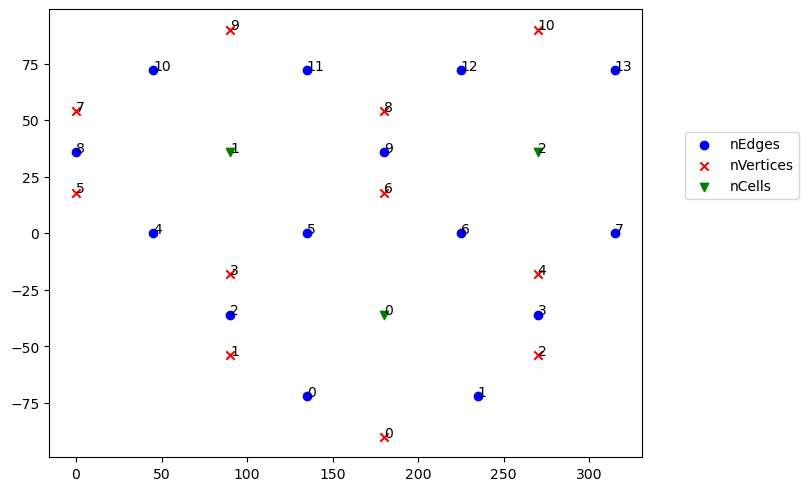

In [172]:
fig,ax=plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ax.scatter(np.rad2deg(ds.lonEdge),np.rad2deg(ds.latEdge),color='blue',label='nEdges')
ax.scatter(np.rad2deg(ds.lonVertex),np.rad2deg(ds.latVertex),marker='x',color='red',label='nVertices')
ax.scatter(np.rad2deg(ds.lonCell), np.rad2deg(ds.latCell),marker='v',color='green',label='nCells')
nEdges = ds.nEdges.values
nVertices = ds.nVertices.values
nCells = ds.nCells.values

for i, txt in enumerate(nEdges):
    ax.annotate(txt, (np.rad2deg(ds.lonEdge[i]),np.rad2deg(ds.latEdge[i])))

for i, txt in enumerate(nVertices):
    ax.annotate(txt, (np.rad2deg(ds.lonVertex[i]), np.rad2deg(ds.latVertex[i])))

for i, txt in enumerate(nCells):
    ax.annotate(txt, (np.rad2deg(ds.lonCell[i]), np.rad2deg(ds.latCell[i])))

fig.legend(bbox_to_anchor=(1.25, 0.75))

# test transport creation, finding, sorting functions

### test transect calculation functions ```calculate_transect``` and ```calculate_transect_multiple_pts```

In [173]:
# **** TEST TRANSECT CALCULATION ALGORTHMS ****

def test_calculate_transects(ds):
    from mpasregions.sections import calculate_transects
    # test if basic algorithm works
    target_start_lon, target_start_lat = 90, -30
    target_end_lon, target_end_lat = 180, 60
    test_edges, test_vertices = calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds)
    assert (test_vertices == np.array([3,6,8])).all()
    assert(test_edges == np.array([5,9])).all()

    # test periodicity in x-direction
    target_start_lon, target_start_lat = 0, 18
    target_end_lon, target_end_lat = 270, 18
    test_edges, test_vertices = calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds)
    assert (test_vertices == np.array([5,4])).all()
    assert(test_edges == 7)

    # test periodicity in y-direction
        # the transect should move south to north (90,-54) does not connect to (90,54) directly.
    target_start_lon, target_start_lat = 90, -54
    target_end_lon, target_end_lat = 90, 90
    test_edges, test_vertices = calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds)
    assert(test_vertices == np.array([1,3,5,7,9])).all()
    assert(test_edges == np.array([2,4,8,10])).all()

def test_calculate_transects_multiple_pts(ds):
    from mpasregions.sections import calculate_transects_multiple_pts
    # calculate_transects_multiple_pts(segment_lons,segment_lats,ds)

    # test if basic algorithm works
    target_lons = np.array([90,90,180])
    target_lats = np.array([-18,90,18])
    test_edges, test_vertices = calculate_transects_multiple_pts(target_lons, target_lats, ds)
    assert(test_vertices == np.array([3,5,7,9,8,6])).all()
    assert(test_edges == np.array([4,8,10,11,9,5])).all()

    # test periodicity in x-direction
    target_lons = np.array([270,360,180]) 
    target_lats = np.array([0,0,0])
    test_edges, test_vertices = calculate_transects_multiple_pts(target_lons, target_lats, ds)
    assert(test_vertices == np.array([4,5,3,6])).all()
    assert(test_edges == np.array([7,4,5,6])).all()

    # test periodicity in y-direction
    target_lons = np.array([90,180,270])
    target_lats = np.array([-54,-90,90])
    test_edges, test_vertices = calculate_transects_multiple_pts(target_lons, target_lats, ds)
    assert(test_vertices == np.array([1,0,1,3,5,7,10,7,5,3])).all()

In [174]:

# # test if you can create a transect bounded by two lines of latitude that wrap around the entire globe
# this block does not exist (idk what to do about this transect yet), and we will pretend that this is fine
# compute_mpas_transect_masks???

# target_lons = np.array([270,180,90,0,90,180,270,0])
# target_lats = np.array([-18,18,-18,18,90,54,90,54])
# test_edges, test_vertices = mps.calculate_transects_multiple_pts(target_lons, target_lats, ds)

# test_vertices = np.array([ 4,  6,  3,  5,  7,  9,  8, 10,  7,  5])
# path = './'
# filename = 'test_latitude_boundaries'
# geojson_file_name = 'test if geojson file identifies all cells inside transect defined along (somewhat) lines of latitude'
# tags = 'unstructured_hexagonal_grid;test_latitude_boundaries_transect'
# author = 'Kaila Uyeda'
# geojson_vertexLats, geojson_vertexLons, dsMasks = mps.transect_from_alg_create_nc(test_vertices, ds, path, filename, geojson_file_name, tags, author)

In [175]:
test_calculate_transects(ds)

broken because reached end vertex
broken because reached end vertex
broken because reached end vertex


In [176]:
test_calculate_transects_multiple_pts(ds)

broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex


### test mask-creating function ```test_transect_from_alg_create_nc```

In [177]:
def test_transect_from_alg_create_nc(ds):
    from mpasregions.sections import transect_from_alg_create_nc
    
    # test basic algorithm
    test_vertices = np.array([3, 5, 7, 9, 8, 6])
    path = './'
    filename = 'test_basic_alg'
    geojson_file_name = 'basic test if transect_from_alg_create_nc works'
    tags = 'unstructured_hexagonal_grid;test_basic'
    author = 'Kaila Uyeda'
    geojson_vertexLats, geojson_vertexLons, dsMasks = transect_from_alg_create_nc(test_vertices, ds, path, filename, geojson_file_name, tags, author)
    assert(geojson_vertexLats == np.array([-18.,  18.,  54.,  90.,  54.,  18.])).all()
    assert(geojson_vertexLons == np.array([ 90.,   0.,   0.,  90., 180., 180.])).all()
           
    # test transects that cross over themselves
    # geojson file should maintain vertices and edges that are not connected to cells inside the desired region
    # mask that is created should only include cells inside the desired region
    test_vertices = np.array([9, 8, 6, 4, 6, 3, 5, 7])
    path = './'
    filename = 'test_crossing_transect'
    geojson_file_name = 'test if geojson file keeps vertices from transect'
    tags = 'unstructured_hexagonal_grid;test_crossing_transect'
    author = 'Kaila Uyeda'
    geojson_vertexLats, geojson_vertexLons, dsMasks = transect_from_alg_create_nc(test_vertices, ds, path, filename, geojson_file_name, tags, author)
    assert(geojson_vertexLats == np.array([ 90.,  54.,  18., -18.,  18., -18.,  18.,  54.])).all()
    assert(geojson_vertexLons == np.array([ 90., 180., 180., 270., 180.,  90.,   0.,   0.])).all()
    assert(dsMasks.isel(nRegions=0).regionCellMasks.values == np.array([0,1,0])).all()


In [178]:
test_transect_from_alg_create_nc(ds)

test_basic_alg_transect_from_alg.geojson exists!
Opening test_basic_alg_transect_from_alg.nc as dsMasks
test_crossing_transect_transect_from_alg.geojson exists!
Opening test_crossing_transect_transect_from_alg.nc as dsMasks


### test ```find_transect_edges_and_vertices``` function

In [179]:
def test_find_transect_edges_and_vertices(ds):
    from mpasregions.sections import find_transect_edges_and_vertices

    # test basic algorithm around a single cell
    # should return edges and vertices that surround that cell
    regionCellMasks_array = np.int32(np.array([[0],[1],[0]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    )) 
    xr_mask_transect_edges, xr_mask_transect_vertices = find_transect_edges_and_vertices(ds, ds_mask)
    assert(xr_mask_transect_edges == np.array([ 4,  5,  8,  9, 10, 11])).all()
    assert(xr_mask_transect_vertices == np.array([3, 5, 6, 7, 8, 9])).all()

    # test basic algorithm around multiple cells
    # edge between the two cells should not be included
    regionCellMasks_array = np.int32(np.array([[1],[1],[0]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    xr_mask_transect_edges, xr_mask_transect_vertices = find_transect_edges_and_vertices(ds, ds_mask)
    assert(xr_mask_transect_edges == np.array([ 0,  1,  2,  3,  4,  6,  8,  9, 10, 11])).all()
    assert(xr_mask_transect_vertices == np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])).all()

    # test basic algorithm that requires crossing a periodic boundary (cells on either side of the boundary are included in the mask)
    # edge between the two cells that border the boundary (0/360) should not be included
    regionCellMasks_array = np.int32(np.array([[0],[1],[1]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    xr_mask_transect_edges, xr_mask_transect_vertices = find_transect_edges_and_vertices(ds, ds_mask)
    assert(xr_mask_transect_edges == np.array([ 4,  5,  6,  7, 10, 11, 12, 13])).all()
    assert(xr_mask_transect_vertices == np.array([ 3,  4,  5,  6,  7,  8,  9, 10])).all()

In [180]:
test_find_transect_edges_and_vertices(ds)

### test ```sorted_transect_edges_and_vertices``` function

In [181]:
def test_sorted_transect_edges_and_vertices(ds):
    from mpasregions.sections import sorted_transect_edges_and_vertices
    # test basic algorithm (vertices and edges around a single cell)
    xr_mask_transect_edges = np.array([ 4,  5,  8,  9, 10, 11])
    xr_mask_transect_vertices = np.array([3, 5, 6, 7, 8, 9])
    sorted_edges, sorted_vertices = sorted_transect_edges_and_vertices(ds, xr_mask_transect_edges, xr_mask_transect_vertices)
    assert(sorted_edges == np.array([ 4,  5,  9, 11, 10,  8])).all()
    assert(sorted_vertices == np.array([3, 6, 8, 9, 7, 5])).all()
    
    # test basic algorithm aroudn 2 cells
    xr_mask_transect_edges = np.array([ 0,  1,  2,  3,  4,  6,  8,  9, 10, 11])
    xr_mask_transect_vertices = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    sorted_edges, sorted_vertices = sorted_transect_edges_and_vertices(ds, xr_mask_transect_edges, xr_mask_transect_vertices)
    assert(sorted_edges == np.array([ 0,  1,  3,  6,  9, 11, 10,  8,  4,  2])).all()
    assert(sorted_vertices == np.array([0, 2, 4, 6, 8, 9, 7, 5, 3, 1])).all()
    
    # test algorithm for mask bounded with complete lines of latitude
    # should have a broken transect that "switches" from the lower boundary to the upper boundary
    xr_mask_transect_edges = np.array([ 4,  5,  6,  7, 10, 11, 12, 13])
    xr_mask_transect_vertices = np.array([ 3,  4,  5,  6,  7,  8,  9, 10])
    sorted_edges, sorted_vertices = sorted_transect_edges_and_vertices(ds, xr_mask_transect_edges, xr_mask_transect_vertices)
    assert(sorted_edges == np.array([ 4,  5,  6,  7, 10, 13, 12, 11])).all()
    assert(sorted_vertices == np.array([ 3,  6,  4,  5,  7, 10,  8,  9])).all()

In [182]:
test_sorted_transect_edges_and_vertices(ds)

switching transects at  4


### test combined find and sort functions ```find_and_sort_transect_edges_and_vertices```

In [183]:
def test_find_and_sort_transect_edges_and_vertices(ds):
    from mpasregions.sections import find_and_sort_transect_edges_and_vertices
    # test basic algorithm 
    # mask around a single cell
    regionCellMasks_array = np.int32(np.array([[0],[1],[0]]))
    ds_mask = xr.Dataset(
            data_vars = dict(
                regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
        ))
    next_edges, next_vertices = find_and_sort_transect_edges_and_vertices(ds, ds_mask)
    assert(next_edges == np.array([ 4,  5,  9, 11, 10,  8])).all()
    assert(next_vertices == np.array([3, 6, 8, 9, 7, 5])).all()

    # test basic algorithm
    # mask around two cells
    regionCellMasks_array = np.int32(np.array([[1],[1],[0]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    next_edges, next_vertices = find_and_sort_transect_edges_and_vertices(ds, ds_mask)
    assert(next_edges == np.array([ 0,  1,  3,  6,  9, 11, 10,  8,  4,  2])).all()
    assert(next_vertices == np.array([0, 2, 4, 6, 8, 9, 7, 5, 3, 1])).all()

    # test algorithm for mask bounded with complete lines of latitude
    # should have a broken transect that "switchees from the lower boundary to the upper boundary
    regionCellMasks_array = np.int32(np.array([[0],[1],[1]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    next_edges, next_vertices = find_and_sort_transect_edges_and_vertices(ds, ds_mask)
    assert(next_edges == np.array([ 4,  5,  6,  7, 10, 13, 12, 11])).all()
    assert(next_vertices == np.array([ 3,  6,  4,  5,  7, 10,  8,  9])).all()

In [184]:
test_find_and_sort_transect_edges_and_vertices(ds)

switching transects at  4


# test transport calculations

In [185]:
def test_scenarios(test_type):
    if test_type == 'basic_single':
        # copy and paste these datasets for whatever scenario you want to test
        # basic algorithm around a single cell
        regionCellMasks_array = np.int32(np.array([[0],[1],[0]]))
        ds_mask = xr.Dataset(
                data_vars = dict(
                    regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                    regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
            ))
        next_edges = np.array([ 4,  5,  9, 11, 10,  8])
        next_vertices = np.array([3, 6, 8, 9, 7, 5])
        
    if test_type == 'basic_double':
        # basic algorithm around two cells
        regionCellMasks_array = np.int32(np.array([[1],[1],[0]]))
        ds_mask = xr.Dataset(
            data_vars = dict(
                regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
        ))
        next_edges = np.array([ 0,  1,  3,  6,  9, 11, 10,  8,  4,  2])
        next_vertices = np.array([0, 2, 4, 6, 8, 9, 7, 5, 3, 1])
        
    if test_type == 'latitude_lines':
        # for a mask bounded by complete lines of latitude
        # zero clue how to ~create~ a mask for a transect like this using an algorithm, but maybe from a mask?
        regionCellMasks_array = np.int32(np.array([[0],[1],[1]]))
        ds_mask = xr.Dataset(
            data_vars = dict(
                regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
        ))
        next_edges = np.array([ 4,  5,  6,  7, 10, 13, 12, 11])
        next_vertices = np.array([ 3,  6,  4,  5,  7, 10,  8,  9])

    return next_edges, next_vertices, ds_mask

### test `format_transect_data`

In [241]:
def test_format_transect_data(ds):
    from mpasregions.sections import format_transect_data

    # test basic algorithm
    edges, vertices, ds_mask = test_scenarios('basic_single')
    ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)
    
    assert(ds_transect_edges.transect_edgesOrdered == np.arange(0,len(edges))).all()
    np.testing.assert_equal(ds_transect_cellsOnEdge.values, np.array([[1, np.nan],[0, 1], [1, 2],[1, np.nan],[1, np.nan],[1, 2]]))

    # test basic algorithm around two cells
    edges, vertices, ds_mask = test_scenarios('basic_double')
    ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)

    assert(ds_transect_edges.transect_edgesOrdered == np.arange(0,len(edges))).all()
    np.testing.assert_equal(ds_transect_cellsOnEdge.values, np.array([[0,np.nan],[0,np.nan],[0,np.nan],[0,2],[1,2],[1,np.nan],[1,np.nan],[1,2],[1,np.nan],[0,np.nan]]))

    # test a mask bounded by complete lines of latitude
    edges, vertices, ds_mask = test_scenarios('latitude_lines')
    ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)

    assert(ds_transect_edges.transect_edgesOrdered == np.arange(0,len(edges))).all()
    np.testing.assert_equal(ds_transect_cellsOnEdge.values, np.array([[1,np.nan],[0,1],[0,2],[2,np.nan],[1,np.nan],[2,np.nan],[2,np.nan],[1,np.nan]]))

In [242]:
test_format_transect_data(ds)

### test ```calculate_velo_into_mask```
**You need to replace the nans in cellsOnEdge with 0s***

In [243]:
def test_kwargs(datavariable='lonCell'):
    a = ds[datavariable]
    return a

In [244]:
a = test_kwargs()
a

<xarray.DataArray 'lonCell' (nCells: 3)> Size: 24B
array([3.14159265, 1.57079633, 4.71238898])
Coordinates:
  * nCells   (nCells) int64 24B 0 1 2

In [218]:
def calculate_velo_into_mask(ds_transect_edges, xr_cellsOnTransectEdges, global_ds, mask, edges, datavariable='timeMonthly_avg_normalVelocity'):
    """
    Calculate the normal velocity into the mask
    Positive --> into the mask
    Negative --> out of the mask
    Parameters
    ----------
    ds_transect_edges: xarray.core.dataset.Dataset
        dataset containing normal velocities to nEdges with coordinates nEdges such that the only nEdges included are in the transect (not the entire global dataset)

    datavariable: str
        string denoting a datavariable in the ds_transect_edges dataset. datavariable must sit on nEdges. We will calculate the flux of this datavariable in calculate_transport_into_mask.
    
    xr_cellsOnTransectEdges: xarray.core.dataarray.DataArray
        dataarray of 'cellsOnEdge' datavariable with coordinates (nEdges,TWO) such that the only nEdges included are in the transect (not the entire global dataset)

    global_ds: xarray.core.dataset.Dataset
        dataset containing grid characteristics for the entire global dataset (not just the masked area or the transect)

    mask: xarray.core.dataset.Dataset
        dataset containing mesh face (vertex/edge/facet) variables of the mask. 

    edges: numpy.ndarray
        array of edges inside a mask (defined using either mps.open_transect_from_alg or mps.open_from_mask)

    Returns
    -------
    ds_transect_edges_NaNs: xarray.core.dataset.Dataset
        original ds_transect_edge dataset with ['veloIntoMask'] datavariable with NaNs filling the land grid cells.
        
    """

    # make land cells that have no value (nCells = -1) NaNs
    xr_cellsOnTransectEdges_minus1 = ds_transect_edges.where(xr_cellsOnTransectEdges >= 0)
    
    # make land cells that are given a small datavariable to represent land NaNs
    # keep cells where the layer thickness is not a nan (would be a NaN from previous operation)
    # keep cells where the layer thickness > 0 
    # by applying the mask based on layerThickness, all other datavariables will also have nans in the same location
    # (layerThickness = 0 tells us there is land at that location)
    
    ocean_only = (~np.isnan(ds_transect_edges.timeMonthly_avg_layerThickness)) & (ds_transect_edges.timeMonthly_avg_layerThickness > 0)
    ds_transect_edges_NaNs = xr_cellsOnTransectEdges_minus1.where(ocean_only)

    #########    
    ds_transect_edges_NaNs['veloIntoMask'] = xr.zeros_like(ds_transect_edges_NaNs[datavariable])
    # ds_transect_edges_NaNs['veloIntoMask'] = ds_transect_edges_NaNs.timeMonthly_avg_normalVelocity * 0
    
    # .isel the mesh to only get the sorted edges on the transect (identified already in dss_transect_edges)
    # global_ds_transect_edges = ds_transect_edges.isel(nEdges = ds_transect_edges.nEdges)
    
    # find transect edges that border land using the cellsOnEdge variable from the mesh
    xr_transect_edgesOnLand_TWO0 = ds_transect_edges_NaNs.nEdges.where(np.isin(ds_transect_edges.cellsOnEdge.isel(TWO=0),0))
    xr_transect_edgesOnLand_TWO1 = ds_transect_edges_NaNs.nEdges.where(np.isin(ds_transect_edges.cellsOnEdge.isel(TWO=1),0))
    xr_transect_edgesOnLand = np.union1d(xr_transect_edgesOnLand_TWO0, xr_transect_edgesOnLand_TWO1)
    
    # find transect edges that border ocean (all transect edges NOT bordering land)
    xr_transect_edgesOnOcean = np.setxor1d(edges, xr_transect_edgesOnLand)
    
    # find the cells that lie on the transect open ocean edges
    n_transect_cellsOnOceanEdges = ds_transect_edges_NaNs.cellsOnEdge
    xr_transect_cellsOnOceanEdges = mps.n_to_xr_idx(n_transect_cellsOnOceanEdges)
    
    # select all the cells inside the mask
    xr_cells_inside, ignore_xr_edges_inside, ignore_xr_vertices_inside = mps.xr_inside_mask_info(global_ds,mask)

    # determine if the normal velocity points into or out of the mask 
    for i in range(0,len(xr_transect_cellsOnOceanEdges)):
        for j in range(0,len(ds_transect_edges_NaNs.xtime_startMonthly)):
            cellsOnSelectedEdge = xr_transect_cellsOnOceanEdges.isel(nEdges = i)
            selectedEdge = np.int32(ds_transect_edges_NaNs.nEdges.isel(nEdges = i))
            selectedMonth = ds_transect_edges_NaNs.xtime_startMonthly.isel(xtime_startMonthly=j)
    
            if cellsOnSelectedEdge.isel(TWO=0).isin(xr_cells_inside): # if A is inside the mask
                ds_transect_edges_NaNs.veloIntoMask.loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] = ds_transect_edges_NaNs[datavariable].loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] * -1
    
            elif cellsOnSelectedEdge.isel(TWO=1).isin(xr_cells_inside): # if B is inside the mask
                ds_transect_edges_NaNs.veloIntoMask.loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] = ds_transect_edges_NaNs[datavariable].loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] * 1

    return ds_transect_edges_NaNs

In [249]:
edges, vertices, ds_mask = test_scenarios('basic_double')
ds_transect_cellsOnEdge, ds_transect_edges = mps.format_transect_data(ds, edges)

In [251]:
b, use = mps.format_transect_data(ds,edges)

In [257]:
# format_transect_data
xr_cellsOnTransectEdges = mps.n_to_xr_idx(ds.cellsOnEdge.isel(nEdges = edges))

# create mask where land cells (nans) are zeros
nans_cellMask = ds.cellsOnEdge.isel(nEdges = edges) == 0

# conduct an isel
ds_transect_edges_raw = ds.isel(nEdges = edges, nCells = xr_cellsOnTransectEdges)

# apply the nans_cellMask (where (identified by edges) the cellsOnEdge should be 0 but is actually currently -1)
ds_transect_edges = ds_transect_edges_raw.where(~nans_cellMask)
ds_transect_edges['nCells'] = ds_transect_edges.nCells.where(~nans_cellMask)

# make a datavariable that holds the order of the nEdges in the transect
ds_transect_edges['transect_edgesOrdered'] = xr.DataArray(np.arange(0,edges.size),dims='nEdges')

# we now have a dataset with cells and edges that are bordering the transect surrounding the mask
ds_transect_edges = ds_transect_edges.assign_coords({'transect_edgesOrdered': ds_transect_edges.transect_edgesOrdered})


In [263]:
ds_transect_edges_raw

<xarray.Dataset> Size: 3kB
Dimensions:                         (nEdges: 10, TWO: 2, nVertices: 11,
                                     vertexDegree: 3, maxEdges: 7,
                                     nVertLevels: 3, xtime_startMonthly: 1)
Coordinates:
    nCells                          (nEdges, TWO) int64 160B 0 2 0 2 ... 1 2 0 2
  * nEdges                          (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
  * nVertices                       (nVertices) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * xtime_startMonthly              (xtime_startMonthly) |S64 64B b'0063-12-0...
    VertexID                        (nVertices) int64 88B 1 2 3 4 ... 8 9 10 11
Dimensions without coordinates: TWO, vertexDegree, maxEdges, nVertLevels
Data variables: (12/14)
    lonCell                         (nEdges, TWO) float64 160B 3.142 ... 4.712
    latCell                         (nEdges, TWO) float64 160B -0.6283 ... 0....
    lonEdge                         (nEdges) float64 80B 2.356 4.102 ... 1.571
    latEdge                         (nEdges) float64 80B -1.257 ... -0.6283
    lonVertex                       (nVertices) float64 88B 3.142 ... 4.712
    latVertex                       (nVertices) float64 88B -1.571 ... 1.571
    ...                              ...
    cellsOnEdge                     (nEdges, TWO) int32 80B 1 0 1 0 ... 2 0 1 0
    verticesOnCell                  (nEdges, TWO, maxEdges) int32 560B 1 2 ... 0
    edgesOnCell                     (nEdges, TWO, maxEdges) int32 560B 1 3 ... 0
    timeMonthly_avg_layerThickness  (nEdges, TWO, nVertLevels) float64 480B 1...
    timeMonthly_avg_normalVelocity  (xtime_startMonthly, nEdges, nVertLevels) float64 240B ...
    dvEdge                          (nEdges) float64 80B 1.881e+05 ... 6.987e+04

In [264]:
ds_transect_edges.nCells

<xarray.DataArray 'nCells' (nEdges: 10, TWO: 2)> Size: 160B
array([[ 0., nan],
       [ 0., nan],
       [ 0., nan],
       [ 0.,  2.],
       [ 1.,  2.],
       [ 1., nan],
       [ 1., nan],
       [ 1.,  2.],
       [ 1., nan],
       [ 0., nan]])
Coordinates:
    nCells                 (nEdges, TWO) float64 160B 0.0 nan 0.0 ... 0.0 nan
  * nEdges                 (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
    transect_edgesOrdered  (nEdges) int64 80B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: TWO

In [261]:
nans_cellMask

<xarray.DataArray 'cellsOnEdge' (nEdges: 10, TWO: 2)> Size: 20B
array([[False,  True],
       [False,  True],
       [False,  True],
       [False, False],
       [False, False],
       [False,  True],
       [False,  True],
       [False, False],
       [False,  True],
       [False,  True]])
Coordinates:
  * nEdges   (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
Dimensions without coordinates: TWO

In [260]:
ds_transect_edges_raw.where(~nans_cellMask)

<xarray.Dataset> Size: 14kB
Dimensions:                         (nEdges: 10, TWO: 2, nVertices: 11,
                                     vertexDegree: 3, maxEdges: 7,
                                     nVertLevels: 3, xtime_startMonthly: 1)
Coordinates:
    nCells                          (nEdges, TWO) int64 160B 0 2 0 2 ... 1 2 0 2
  * nEdges                          (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
  * nVertices                       (nVertices) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * xtime_startMonthly              (xtime_startMonthly) |S64 64B b'0063-12-0...
    VertexID                        (nVertices) int64 88B 1 2 3 4 ... 8 9 10 11
Dimensions without coordinates: TWO, vertexDegree, maxEdges, nVertLevels
Data variables: (12/14)
    lonCell                         (nEdges, TWO) float64 160B 3.142 nan ... nan
    latCell                         (nEdges, TWO) float64 160B -0.6283 ... nan
    lonEdge                         (nEdges, TWO) float64 160B 2.356 nan ... nan
    latEdge                         (nEdges, TWO) float64 160B -1.257 ... nan
    lonVertex                       (nVertices, nEdges, TWO) float64 2kB 3.14...
    latVertex                       (nVertices, nEdges, TWO) float64 2kB -1.5...
    ...                              ...
    cellsOnEdge                     (nEdges, TWO) float64 160B 1.0 nan ... nan
    verticesOnCell                  (nEdges, TWO, maxEdges) float64 1kB 1.0 ....
    edgesOnCell                     (nEdges, TWO, maxEdges) float64 1kB 1.0 ....
    timeMonthly_avg_layerThickness  (nEdges, TWO, nVertLevels) float64 480B 1...
    timeMonthly_avg_normalVelocity  (xtime_startMonthly, nEdges, nVertLevels, TWO) float64 480B ...
    dvEdge                          (nEdges, TWO) float64 160B 1.881e+05 ... nan

In [221]:
ds_transect_edges, xr_cellsOnTransectEdges, global_ds, mask, edges, datavariable = ds_transect_edges, ds_transect_cellsOnEdge, ds, ds_mask, edges, 'timeMonthly_avg_normalVelocity'
# make land cells that have no value (nCells = -1) NaNs
xr_cellsOnTransectEdges_minus1 = ds_transect_edges.where(xr_cellsOnTransectEdges >= 0)

# make land cells that are given a small datavariable to represent land NaNs
# keep cells where the layer thickness is not a nan (would be a NaN from previous operation)
# keep cells where the layer thickness > 0 
# by applying the mask based on layerThickness, all other datavariables will also have nans in the same location
# (layerThickness = 0 tells us there is land at that location)

ocean_only = (~np.isnan(ds_transect_edges.timeMonthly_avg_layerThickness)) & (ds_transect_edges.timeMonthly_avg_layerThickness > 0)
ds_transect_edges_NaNs = xr_cellsOnTransectEdges_minus1.where(ocean_only)

#########    
ds_transect_edges_NaNs['veloIntoMask'] = xr.zeros_like(ds_transect_edges_NaNs[datavariable])
# ds_transect_edges_NaNs['veloIntoMask'] = ds_transect_edges_NaNs.timeMonthly_avg_normalVelocity * 0

# .isel the mesh to only get the sorted edges on the transect (identified already in dss_transect_edges)
# global_ds_transect_edges = ds_transect_edges.isel(nEdges = ds_transect_edges.nEdges)

# find transect edges that border land using the cellsOnEdge variable from the mesh
xr_transect_edgesOnLand_TWO0 = ds_transect_edges_NaNs.nEdges.where(np.isin(ds_transect_edges.cellsOnEdge.isel(TWO=0),0))
xr_transect_edgesOnLand_TWO1 = ds_transect_edges_NaNs.nEdges.where(np.isin(ds_transect_edges.cellsOnEdge.isel(TWO=1),0))
xr_transect_edgesOnLand = np.union1d(xr_transect_edgesOnLand_TWO0, xr_transect_edgesOnLand_TWO1)

# find transect edges that border ocean (all transect edges NOT bordering land)
xr_transect_edgesOnOcean = np.setxor1d(edges, xr_transect_edgesOnLand)

# find the cells that lie on the transect open ocean edges
n_transect_cellsOnOceanEdges = ds_transect_edges_NaNs.cellsOnEdge
xr_transect_cellsOnOceanEdges = mps.n_to_xr_idx(n_transect_cellsOnOceanEdges)

# select all the cells inside the mask
xr_cells_inside, ignore_xr_edges_inside, ignore_xr_vertices_inside = mps.xr_inside_mask_info(global_ds,mask)

# determine if the normal velocity points into or out of the mask 
for i in range(0,len(xr_transect_cellsOnOceanEdges)):
    for j in range(0,len(ds_transect_edges_NaNs.xtime_startMonthly)):
        cellsOnSelectedEdge = xr_transect_cellsOnOceanEdges.isel(nEdges = i)
        selectedEdge = np.int32(ds_transect_edges_NaNs.nEdges.isel(nEdges = i))
        selectedMonth = ds_transect_edges_NaNs.xtime_startMonthly.isel(xtime_startMonthly=j)

        if cellsOnSelectedEdge.isel(TWO=0).isin(xr_cells_inside): # if A is inside the mask
            ds_transect_edges_NaNs.veloIntoMask.loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] = ds_transect_edges_NaNs[datavariable].loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] * -1

        elif cellsOnSelectedEdge.isel(TWO=1).isin(xr_cells_inside): # if B is inside the mask
            ds_transect_edges_NaNs.veloIntoMask.loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] = ds_transect_edges_NaNs[datavariable].loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] * 1


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
# make these nans

In [246]:
ds.timeMonthly_avg_normalVelocity

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (xtime_startMonthly: 1,
                                                    nEdges: 14, nVertLevels: 3)> Size: 336B
array([[[ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [-1.  ,  0.  ,  0.  ],
        [ 0.75,  0.5 ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [-1.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ]]])
Coordinates:
  * nEdges              (nEdges) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
  * xtime_startMonthly  (xtime_startMonthly) |S64 64B b'0063-12-01_00:30:00'
Dimensions without coordinates: nVertLevels

In [239]:
ds.timeMonthly_avg_normalVelocity

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (xtime_startMonthly: 1,
                                                    nEdges: 14, nVertLevels: 3)> Size: 336B
array([[[ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [-1.  ,  0.  ,  0.  ],
        [ 0.75,  0.5 ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [-1.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ]]])
Coordinates:
  * nEdges              (nEdges) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
  * xtime_startMonthly  (xtime_startMonthly) |S64 64B b'0063-12-01_00:30:00'
Dimensions without coordinates: nVertLevels

In [237]:
ds_transect_edges.timeMonthly_avg_normalVelocity#.isel(xtime_startMonthly=0,nEdges=5)

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (xtime_startMonthly: 1,
                                                    nEdges: 10, nVertLevels: 3,
                                                    TWO: 2)> Size: 480B
array([[[[ 0.  ,   nan],
         [ 0.  ,   nan],
         [ 0.  ,   nan]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [ 0.  ,   nan]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [ 0.  ,   nan]],

        [[ 0.75,  0.75],
         [ 0.5 ,  0.5 ],
         [ 0.  ,  0.  ]],

        [[ 0.  ,  0.  ],
         [ 0.  ,  0.  ],
         [ 0.  ,  0.  ]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [ 0.  ,   nan]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [ 0.  ,   nan]],

        [[-1.  , -1.  ],
         [ 0.  ,  0.  ],
         [ 0.  ,  0.  ]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [ 0.  ,   nan]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [ 0.  ,   nan]]]])
Coordinates:
    nCells                 (nEdges, TWO) float64 160B 0.0 nan 0.0 ... 0.0 nan
  * nEdges                 (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
  * xtime_startMonthly     (xtime_startMonthly) |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  (nEdges) int64 80B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: nVertLevels, TWO

In [232]:
xr_cellsOnTransectEdges_minus1.timeMonthly_avg_normalVelocity.isel(xtime_startMonthly=0)

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (nEdges: 10, nVertLevels: 3,
                                                    TWO: 2)> Size: 480B
array([[[ 0.  ,   nan],
        [ 0.  ,   nan],
        [ 0.  ,   nan]],

       [[ 0.  ,   nan],
        [ 0.  ,   nan],
        [ 0.  ,   nan]],

       [[ 0.  ,   nan],
        [ 0.  ,   nan],
        [ 0.  ,   nan]],

       [[ 0.75,  0.75],
        [ 0.5 ,  0.5 ],
        [ 0.  ,  0.  ]],

       [[ 0.  ,  0.  ],
        [ 0.  ,  0.  ],
        [ 0.  ,  0.  ]],

       [[ 0.  ,   nan],
        [ 0.  ,   nan],
        [ 0.  ,   nan]],

       [[ 0.  ,   nan],
        [ 0.  ,   nan],
        [ 0.  ,   nan]],

       [[-1.  , -1.  ],
        [ 0.  ,  0.  ],
        [ 0.  ,  0.  ]],

       [[ 0.  ,   nan],
        [ 0.  ,   nan],
        [ 0.  ,   nan]],

       [[ 0.  ,   nan],
        [ 0.  ,   nan],
        [ 0.  ,   nan]]])
Coordinates:
    nCells                 (nEdges, TWO) float64 160B 0.0 nan 0.0 ... 0.0 nan
  * nEdges                 (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
    xtime_startMonthly     |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  (nEdges) int64 80B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: nVertLevels, TWO

In [233]:
ds.timeMonthly_avg_normalVelocity

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (xtime_startMonthly: 1,
                                                    nEdges: 14, nVertLevels: 3)> Size: 336B
array([[[ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [-1.  ,  0.  ,  0.  ],
        [ 0.75,  0.5 ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [-1.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ],
        [ 0.  ,  0.  ,  0.  ]]])
Coordinates:
  * nEdges              (nEdges) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
  * xtime_startMonthly  (xtime_startMonthly) |S64 64B b'0063-12-01_00:30:00'
Dimensions without coordinates: nVertLevels

In [222]:
ds.timeMonthly_avg_normalVelocity.isel(xtime_startMonthly=0,nEdges=5)

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (nVertLevels: 3)> Size: 24B
array([-1.,  0.,  0.])
Coordinates:
    nEdges              int64 8B 5
    xtime_startMonthly  |S64 64B b'0063-12-01_00:30:00'
Dimensions without coordinates: nVertLevels

In [223]:
ds_transect_edges_NaNs.timeMonthly_avg_normalVelocity.isel(xtime_startMonthly=0,nEdges=5)

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (nVertLevels: 3, TWO: 2)> Size: 48B
array([[ 0., nan],
       [nan, nan],
       [nan, nan]])
Coordinates:
    nCells                 (TWO) float64 16B 1.0 nan
    nEdges                 int64 8B 11
    xtime_startMonthly     |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  int64 8B 5
Dimensions without coordinates: nVertLevels, TWO

In [212]:
ds_transect_edges_NaNs.timeMonthly_avg_normalVelocity.isel(nEdges=0,xtime_startMonthly=0,nVertLevels=0)

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (TWO: 2)> Size: 16B
array([ 0., nan])
Coordinates:
    nCells                 (TWO) float64 16B 0.0 nan
    nEdges                 int64 8B 0
    xtime_startMonthly     |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  int64 8B 0
Dimensions without coordinates: TWO

In [209]:
xr_transect_cellsOnOceanEdges

<xarray.DataArray 'cellsOnEdge' (nEdges: 10, TWO: 2, nVertLevels: 3)> Size: 480B
array([[[ 0.,  0., nan],
        [nan, nan, nan]],

       [[ 0.,  0., nan],
        [nan, nan, nan]],

       [[ 0.,  0., nan],
        [nan, nan, nan]],

       [[ 0.,  0., nan],
        [ 2.,  2., nan]],

       [[ 1., nan, nan],
        [ 2.,  2., nan]],

       [[ 1., nan, nan],
        [nan, nan, nan]],

       [[ 1., nan, nan],
        [nan, nan, nan]],

       [[ 1., nan, nan],
        [ 2.,  2., nan]],

       [[ 1., nan, nan],
        [nan, nan, nan]],

       [[ 0.,  0., nan],
        [nan, nan, nan]]])
Coordinates:
    nCells                 (nEdges, TWO) float64 160B 0.0 nan 0.0 ... 0.0 nan
  * nEdges                 (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
    transect_edgesOrdered  (nEdges) int64 80B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: TWO, nVertLevels

In [196]:
cellsOnSelectedEdge.isel(TWO=1)

<xarray.DataArray 'cellsOnEdge' (nVertLevels: 3)> Size: 24B
array([nan, nan, nan])
Coordinates:
    nCells                 float64 8B nan
    nEdges                 int64 8B 0
    transect_edgesOrdered  int64 8B 0
Dimensions without coordinates: nVertLevels

In [197]:
ds_transect_edges_NaNs.timeMonthly_avg_normalVelocity

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (xtime_startMonthly: 1,
                                                    nEdges: 10, nVertLevels: 3,
                                                    TWO: 2)> Size: 480B
array([[[[ 0.  ,   nan],
         [ 0.  ,   nan],
         [  nan,   nan]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [  nan,   nan]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [  nan,   nan]],

        [[ 0.75,  0.75],
         [ 0.5 ,  0.5 ],
         [  nan,   nan]],

        [[ 0.  ,  0.  ],
         [  nan,  0.  ],
         [  nan,   nan]],

        [[ 0.  ,   nan],
         [  nan,   nan],
         [  nan,   nan]],

        [[ 0.  ,   nan],
         [  nan,   nan],
         [  nan,   nan]],

        [[-1.  , -1.  ],
         [  nan,  0.  ],
         [  nan,   nan]],

        [[ 0.  ,   nan],
         [  nan,   nan],
         [  nan,   nan]],

        [[ 0.  ,   nan],
         [ 0.  ,   nan],
         [  nan,   nan]]]])
Coordinates:
    nCells                 (nEdges, TWO) float64 160B 0.0 nan 0.0 ... 0.0 nan
  * nEdges                 (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
  * xtime_startMonthly     (xtime_startMonthly) |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  (nEdges) int64 80B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: nVertLevels, TWO

In [198]:
ds.timeMonthly_avg_normalVelocity.isel(xtime_startMonthly=0,nVertLevels=0).shape

(14,)

In [199]:
ds.timeMonthly_avg_normalVelocity.shape

(1, 14, 3)

In [200]:
dso.timeMonthly_avg_normalVelocity

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (Time: 1, nEdges: 719506,
                                                    nVertLevels: 60)> Size: 173MB
[43170360 values with dtype=float32]
Dimensions without coordinates: Time, nEdges, nVertLevels
Attributes:
    units:      m s^{-1}
    long_name:  horizontal velocity, normal component to an edge

In [201]:
ds_transect_edges_NaNs[datavariable].loc[dict(xtime_startMonthly = selectedMonth, nEdges = selectedEdge)] 

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (nVertLevels: 3, TWO: 2)> Size: 48B
array([[ 0., nan],
       [ 0., nan],
       [nan, nan]])
Coordinates:
    nCells                 (TWO) float64 16B 0.0 nan
    nEdges                 int64 8B 0
    xtime_startMonthly     |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  int64 8B 0
Dimensions without coordinates: nVertLevels, TWO

In [202]:
dso.timeMonthly_avg_normalVelocity.loc[dict(Time=0, nEdges = selectedEdge)]

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (nVertLevels: 60)> Size: 240B
[60 values with dtype=float32]
Dimensions without coordinates: nVertLevels
Attributes:
    units:      m s^{-1}
    long_name:  horizontal velocity, normal component to an edge

In [203]:
dso.timeMonthly_avg_normalVelocity

<xarray.DataArray 'timeMonthly_avg_normalVelocity' (Time: 1, nEdges: 719506,
                                                    nVertLevels: 60)> Size: 173MB
[43170360 values with dtype=float32]
Dimensions without coordinates: Time, nEdges, nVertLevels
Attributes:
    units:      m s^{-1}
    long_name:  horizontal velocity, normal component to an edge

In [204]:
ds_transect_edges_NaNs.veloIntoMask

<xarray.DataArray 'veloIntoMask' (xtime_startMonthly: 1, nEdges: 10,
                                  nVertLevels: 3, TWO: 2)> Size: 480B
array([[[[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]]]])
Coordinates:
    nCells                 (nEdges, TWO) float64 160B 0.0 nan 0.0 ... 0.0 nan
  * nEdges                 (nEdges) int64 80B 0 1 3 6 9 11 10 8 4 2
  * xtime_startMonthly     (xtime_startMonthly) |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  (nEdges) int64 80B 0 1 2 3 4 5 6 7 8 9
Dimensions without coordinates: nVertLevels, TWO

In [205]:
ds_transect_edges_NaNs.veloIntoMask.loc[dict(xtime_startMonthly=selectedMonth,nEdges = selectedEdge)]

<xarray.DataArray 'veloIntoMask' (nVertLevels: 3, TWO: 2)> Size: 48B
array([[0., 0.],
       [0., 0.],
       [0., 0.]])
Coordinates:
    nCells                 (TWO) float64 16B 0.0 nan
    nEdges                 int64 8B 0
    xtime_startMonthly     |S64 64B b'0063-12-01_00:30:00'
    transect_edgesOrdered  int64 8B 0
Dimensions without coordinates: nVertLevels, TWO

In [ ]:
xr_transect_cellsOnOceanEdges

In [ ]:
xr_cells_inside

In [ ]:
i

In [ ]:
cellsOnSelectedEdge.isel(TWO=0)

In [ ]:
cellsOnSelectedEdge.isel(TWO=1)

In [ ]:
calculate_velo_into_mask(ds_transect_edges, ds_transect_cellsOnEdge, ds, ds_mask, edges, datavariable='timeMonthly_avg_normalVelocity')


In [ ]:
ds.timeMonthly_avg_layerThickness

In [ ]:
dso.timeMonthly_avg_layerThickness.isel(Time=0,nCells=0,nVertLevels=0).values

In [ ]:
mesh.edgesOnCell.isel(nCells=0).values

In [ ]:
mesh.cellsOnEdge.isel(nEdges = 288637-1).values

In [ ]:
dso.timeMonthly_avg_layerThickness.isel(Time=0,nCells=234052-1,nVertLevels=0).values

In [ ]:
mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/EC30to60E2r2/ocean.EC30to60E2r2.210210.nc'
mesh = xr.open_dataset(mesh_path)
mesh = mesh.assign_coords({
"VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
})

# global data
bmm_filepath = '/pscratch/sd/b/bmoorema/run_001_062/'
dso = xr.open_dataset(bmm_filepath + '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStatsMonthly.0063-12-01.nc')

In [ ]:
dso.timeMonthly_avg_normalVelocity# .isel(Time=0,nEdges=0,nVertLevels=1).values

In [ ]:
mesh.cellsOnEdge.isel(nEdges=0).values

In [ ]:
values, counts = np.unique_counts(dso.timeMonthly_avg_normalVelocity.isel(Time=0))

In [ ]:
values

In [ ]:
counts